# Exploratory Data Analysis

Before we model anything we want to know:

1. How big is the dataset, and is it complete (no missing, no duplicates)?
2. What does the target variable Yield look like, and how does it differ across crop / season / soil type?
3. Do any of the raw input columns have a usable correlation with Yield?

If the answer to question 3 is poor, we will need engineered features in notebook 02.

## Imports

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
RAW_PATH = ROOT / 'data' / 'raw' / 'Agri_yield_prediction.csv'
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Load the raw CSV

In [2]:
df = pd.read_csv(RAW_PATH)
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
df.head()

Rows: 36000
Columns: 46


,Temperature,Humidity,Rainfall,Soil_Type,pH,EC,OC,N,P,K,...,Planting_Date,Harvest_Date,Growth_Stage,Irrigation_Frequency,Fertilizer_Type,Pesticide_Usage,Yield,Region,Season,Year
0,20.217609,71.563782,48.837768,Clayey,6.467371,1.317873,0.656934,138.565862,65.148562,197.716636,...,2023-10-19,2024-01-29,Vegetative,4,Organic,Low,5.340428,West,Rabi,2023
1,34.144330,62.473178,253.900950,Sandy,7.087405,1.564200,0.748017,82.633876,37.236441,99.902932,...,2009-08-23,2009-11-13,Reproductive,4,Mixed,High,6.633464,North,Kharif,2009
2,20.842568,60.215798,128.300095,Loamy,6.685763,1.162799,1.185390,140.045407,72.826335,151.476596,...,2022-12-23,2023-04-11,Vegetative,5,Mixed,High,7.088017,South,Rabi,2022
3,26.367346,60.933355,159.439204,Sandy,7.200194,0.881416,0.794367,109.949204,49.583849,200.372264,...,2023-08-10,2023-11-09,Vegetative,9,Chemical,High,5.798286,North,Kharif,2023
4,24.748865,71.095366,170.084596,Sandy,6.670267,1.547674,1.081402,99.444634,64.207218,174.627078,...,2003-08-05,2003-10-22,Maturity,4,Organic,High,9.923957,South,Kharif,2003


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 46 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature             36000 non-null  float64
 1   Humidity                36000 non-null  float64
 2   Rainfall                36000 non-null  float64
 3   Soil_Type               36000 non-null  object 
 4   pH                      36000 non-null  float64
 5   EC                      36000 non-null  float64
 6   OC                      36000 non-null  float64
 7   N                       36000 non-null  float64
 8   P                       36000 non-null  float64
 9   K                       36000 non-null  float64
 10  Ca                      36000 non-null  float64
 11  Mg                      36000 non-null  float64
 12  S                       36000 non-null  float64
 13  Zn                      36000 non-null  float64
 14  Fe                      36000 non-null

## Data quality

In [4]:
missing = df.isna().sum()
print('Total missing values:', int(missing.sum()))
missing[missing > 0]

Total missing values: 0


Series([], dtype: int64)

In [5]:
duplicates = int(df.duplicated().sum())
print('Duplicate rows:', duplicates)

Duplicate rows: 0


Zero missing values and zero duplicates. No imputation or deduplication needed.

## Yield distribution

In [6]:
df['Yield'].describe().round(3)

count    36000.000
mean         6.430
std          2.296
min          1.000
25%          4.753
50%          6.324
75%          8.235
max         10.000
Name: Yield, dtype: float64

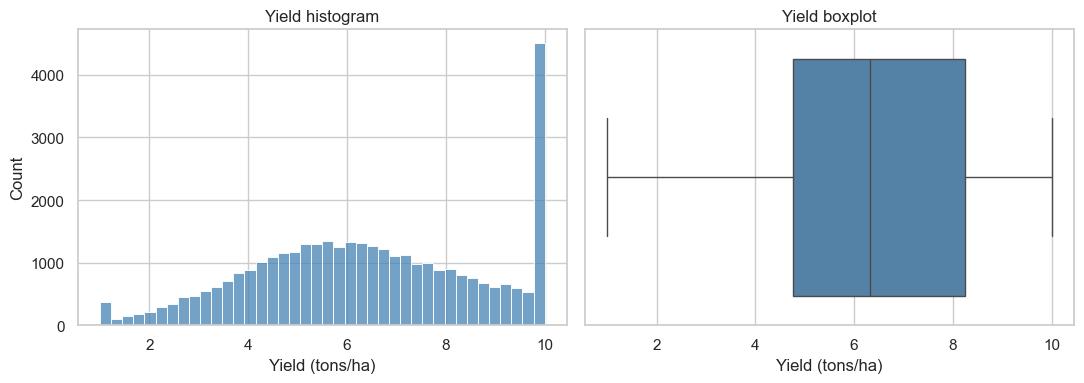

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['Yield'], bins=40, color='steelblue', ax=axes[0])
axes[0].set_title('Yield histogram')
axes[0].set_xlabel('Yield (tons/ha)')
sns.boxplot(x=df['Yield'], color='steelblue', ax=axes[1])
axes[1].set_title('Yield boxplot')
axes[1].set_xlabel('Yield (tons/ha)')
fig.tight_layout()
fig.savefig(FIG_DIR / '01_yield_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Yield is roughly bell-shaped, ranges 1 to 10 tons/ha, mean around 6.4. The boxplot shows no extreme outliers.

## Distributions of a few key numeric features

We don't plot all 36 numeric columns. We pick four that are easy to interpret as a sanity check on the data.

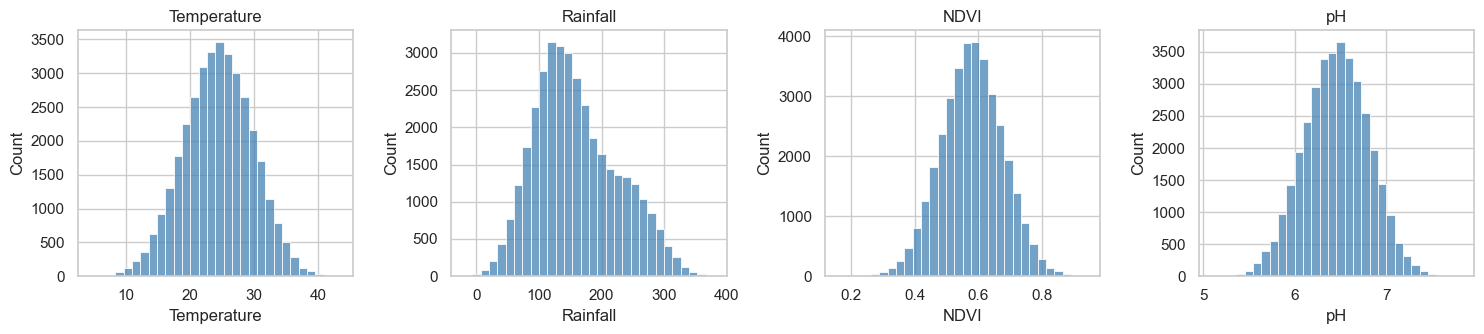

In [8]:
key_cols = ['Temperature', 'Rainfall', 'NDVI', 'pH']
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, col in zip(axes, key_cols):
    sns.histplot(df[col], bins=30, color='steelblue', ax=ax)
    ax.set_title(col)
fig.tight_layout()
fig.savefig(FIG_DIR / 'eda_key_features.png', dpi=150, bbox_inches='tight')
plt.show()

Temperature, Rainfall, NDVI and pH all look like reasonable agronomic ranges, no obvious data corruption.

## Yield broken down by categorical columns

If any single categorical column splits Yield strongly, we have a powerful predictor. If not, single-column information is too weak and we will need feature engineering.

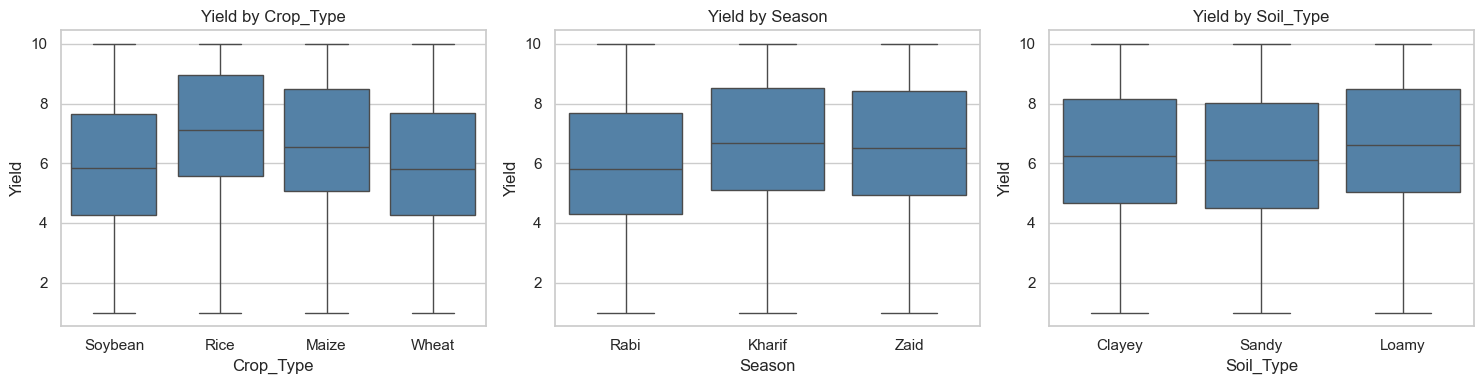

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Crop_Type', 'Season', 'Soil_Type']):
    sns.boxplot(data=df, x=col, y='Yield', color='steelblue', ax=ax)
    ax.set_title(f'Yield by {col}')
fig.tight_layout()
fig.savefig(FIG_DIR / 'eda_yield_by_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
for col in ['Crop_Type', 'Season', 'Soil_Type']:
    print(col)
    print(df.groupby(col)['Yield'].agg(['count', 'mean', 'std']).round(2).to_string())
    print()

Crop_Type
           count  mean   std
Crop_Type                   
Maize       8676  6.69  2.20
Rice        8916  7.11  2.10
Soybean     8638  5.98  2.33
Wheat       9770  5.97  2.34

Season
        count  mean   std
Season                   
Kharif  15006  6.73  2.22
Rabi    13029  5.98  2.34
Zaid     7965  6.60  2.26

Soil_Type
           count  mean   std
Soil_Type                   
Clayey     12235  6.35  2.32
Loamy      13027  6.68  2.24
Sandy      10738  6.22  2.32



All three categorical groupings give nearly identical Yield means (within 0.1 tons/ha) and very similar spreads. None of these columns is a strong solo predictor.

## Class balance for the categorical columns

If a column is dominated by one value the model can't learn from it. We confirm the categories are reasonably balanced.

In [11]:
cat_cols = ['Crop_Type', 'Soil_Type', 'Fertilizer_Type', 'Pesticide_Usage', 'Growth_Stage', 'Region', 'Season']
for col in cat_cols:
    print(col)
    print(df[col].value_counts().to_string())
    print()

Crop_Type
Crop_Type
Wheat      9770
Rice       8916
Maize      8676
Soybean    8638

Soil_Type
Soil_Type
Loamy     13027
Clayey    12235
Sandy     10738

Fertilizer_Type
Fertilizer_Type
Chemical    12281
Mixed       11977
Organic     11742

Pesticide_Usage
Pesticide_Usage
Low       12290
Medium    11876
High      11834

Growth_Stage
Growth_Stage
Vegetative      12205
Maturity        11974
Reproductive    11821

Region
Region
North    9288
West     9010
South    8969
East     8733

Season
Season
Kharif    15006
Rabi      13029
Zaid       7965

